In [1]:
from pathlib import Path
import pandas as pd
import tarfile
import urllib.request

from Classic_Machine_Learning.Chapter_7.Chapter_7 import X_reduced


def download_and_extract_ridership_data():
    tarball_path = Path("datasets/ridership.tgz")
    if not tarball_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/ridership.tgz"
        urllib.request.urlretrieve(url, tarball_path)
        with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall(path="datasets", filter="data")

download_and_extract_ridership_data()

In [2]:
path = Path("datasets/ridership/CTA_-_Ridership_-_Daily_Boarding_Totals.csv")
df = pd.read_csv(path, parse_dates=["service_date"])
df.columns = ["date", "day_type", "bus", "rail", "total"]
df = df.sort_values("date").set_index("date")
df = df.drop("total", axis=1)
df = df.drop_duplicates()

In [3]:
df.head(10)

,day_type,bus,rail
date,,,
2001-01-01,U,297192,126455
2001-01-02,W,780827,501952
2001-01-03,W,824923,536432
2001-01-04,W,870021,550011
2001-01-05,W,890426,557917
2001-01-06,A,577401,255356
2001-01-07,U,375831,169825
2001-01-08,W,985221,590706
2001-01-09,W,978377,599905


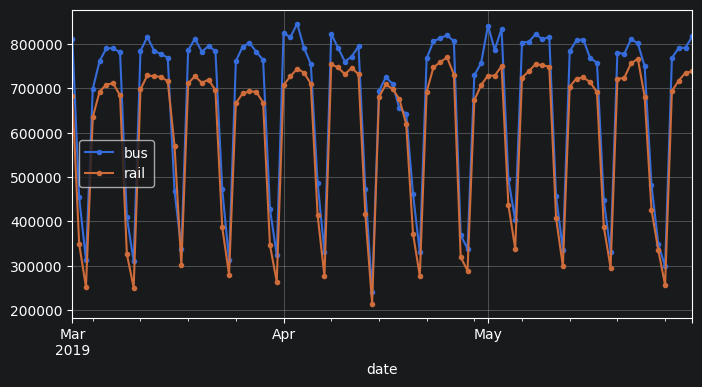

In [4]:
import matplotlib.pyplot as plt

df["2019-03":"2019-05"].plot(grid=True, marker=".", figsize=(8,4))
plt.show()

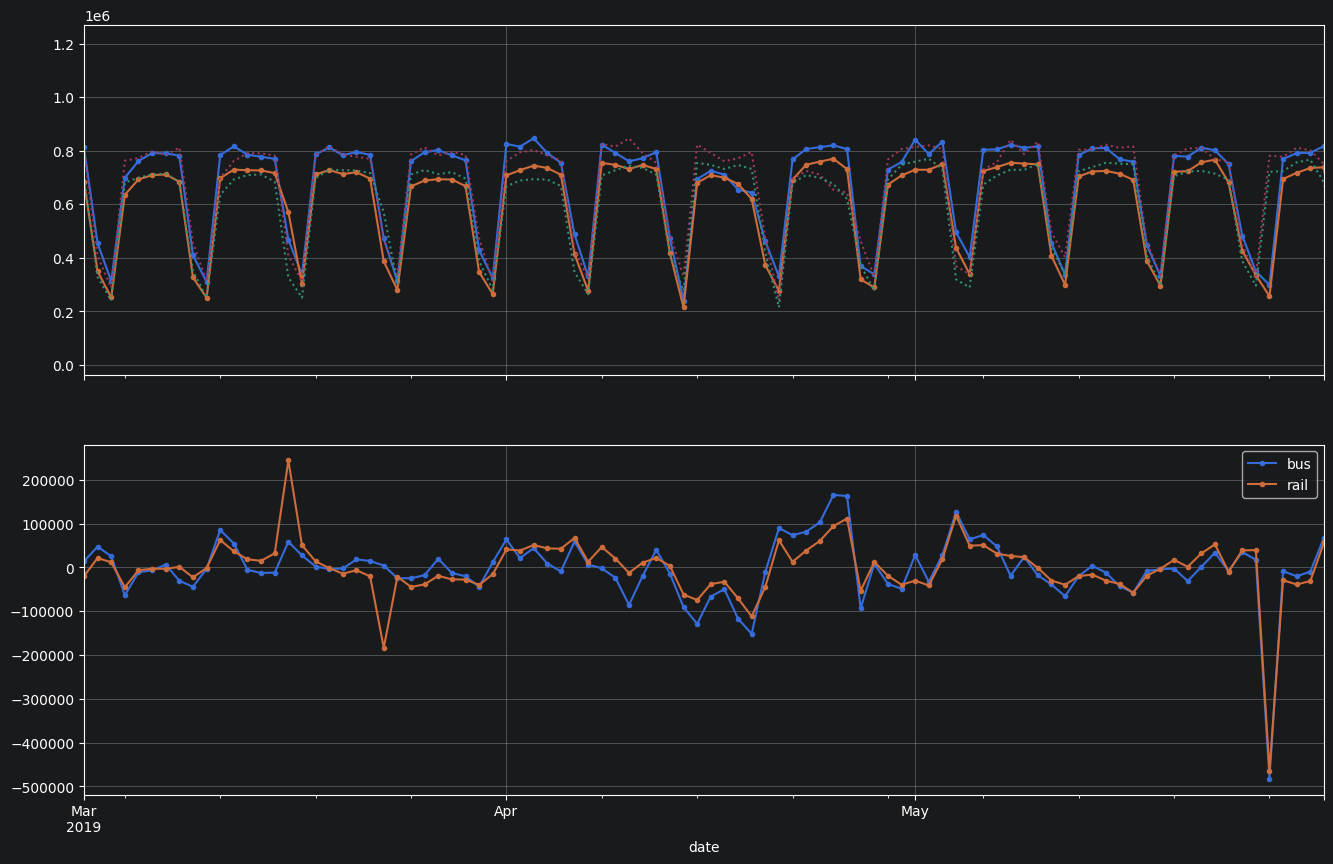

In [5]:
diff_7 = df[["bus", "rail"]].diff(7)["2019-03":"2019-05"]

fig, axs = plt.subplots(2, 1, sharex=True, figsize=(16, 10))
df.plot(ax=axs[0], legend=False, marker=".")
df.shift(7).plot(ax=axs[0], grid=True, legend=False, linestyle=":")
diff_7.plot(ax=axs[1], grid=True, marker=".")
plt.show()

In [6]:
list(df.loc["2019-05-25":"2019-05-27"]["day_type"])

['A', 'U', 'U']

In [7]:
diff_7.abs().mean()

bus     43915.608696
rail    42143.271739
dtype: float64

In [8]:
targets = df[["bus", "rail"]]["2019-03":"2019-05"]
(diff_7 / targets).abs().mean()

bus     0.082938
rail    0.089948
dtype: float64

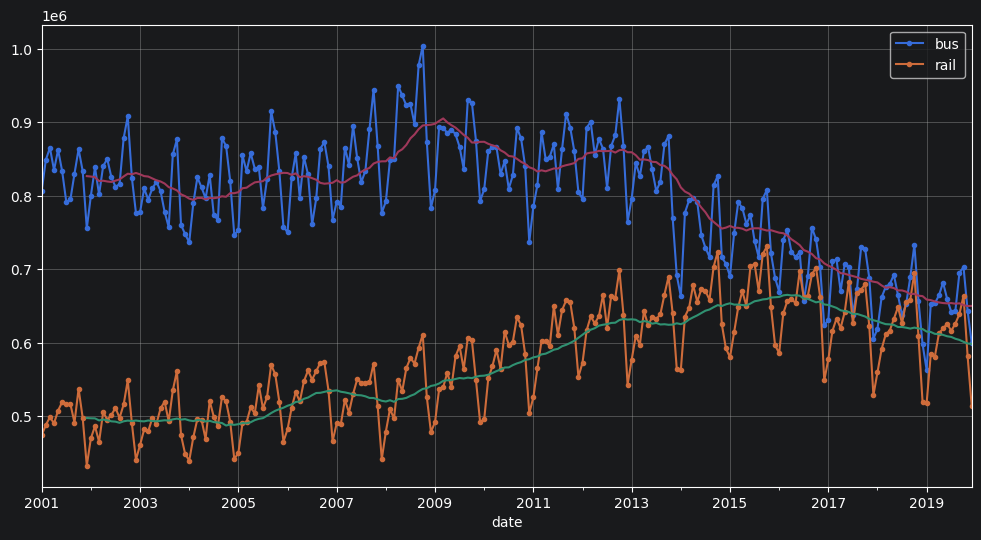

In [9]:
period = slice("2001", "2019")
df_monthly = df.select_dtypes(include="number").resample('ME').mean()
rolling_average_12_months = df_monthly.loc[period].rolling(window=12).mean()

fig, ax = plt.subplots(figsize=(12, 6))
df_monthly[period].plot(ax=ax, marker=".")
rolling_average_12_months.plot(ax=ax, grid=True, legend=False)
plt.show()

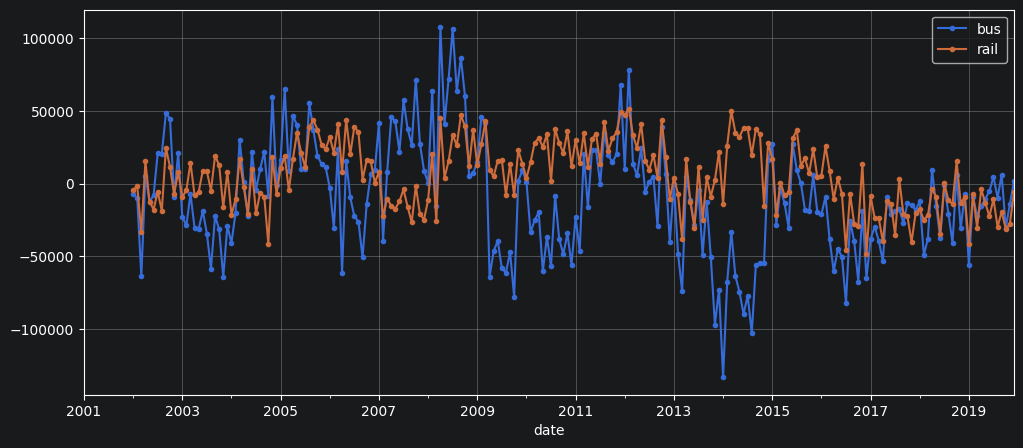

In [10]:
df_monthly.diff(12)[period].plot(grid=True, marker=".", figsize=(12, 5))
plt.show()

In [11]:
from statsmodels.tsa.arima.model import ARIMA

origin, today = "2019-01-01", "2019-05-31"
rail_series = df.loc[origin:today]["rail"].asfreq("D")
model = ARIMA(rail_series,
              order=(1, 0, 0),
              seasonal_order=(0, 1, 1, 7))
model = model.fit()
y_pred = model.forecast()
y_pred

2019-06-01    427758.626421
Freq: D, dtype: float64

In [12]:
origin, start_date, end_date = "2019-01-01", "2019-03-01", "2019-05-31"
time_period = pd.date_range(start_date, end_date)
rail_series = df.loc[origin:end_date]["rail"].asfreq("D")
y_preds = []
for today in time_period.shift(-1):
    model = ARIMA(rail_series[origin:today],  # train on data up to "today"
                  order=(1, 0, 0),
                  seasonal_order=(0, 1, 1, 7))
    model = model.fit()  # note that we retrain the model every day!
    y_pred = model.forecast().iloc[0]
    y_preds.append(y_pred)

y_preds = pd.Series(y_preds, index=time_period)
mae = (y_preds - rail_series[time_period]).abs().mean()  # returns 32,040.7

In [13]:
import torch

class TimeSeriesDataset(torch.utils.data.Dataset):
    def __init__(self, series, window_length):
        self.series = series
        self.window_length = window_length

    def __len__(self):
        return len(self.series) - self.window_length

    def __getitem__(self, idx):
        if idx >= len(self):
            raise IndexError("dataset index out of range")
        end = idx + self.window_length
        window = self.series[idx:end]
        target = self.series[end]
        return window, target

In [14]:
my_series = torch.tensor([[0], [1], [2], [3], [4], [5]])
my_dataset = TimeSeriesDataset(my_series, 3)
for window, target in my_dataset:
    print(f"Window: {window}, Target: {target}")

Window: tensor([[0],
        [1],
        [2]]), Target: tensor([3])
Window: tensor([[1],
        [2],
        [3]]), Target: tensor([4])
Window: tensor([[2],
        [3],
        [4]]), Target: tensor([5])


In [15]:
from torch.utils.data import DataLoader

torch.manual_seed(42)
my_loader = DataLoader(my_dataset, batch_size=2, shuffle=True)
for X, y in my_loader:
    print("X: ", X, " y: ", y)

X:  tensor([[[1],
         [2],
         [3]],

        [[2],
         [3],
         [4]]])  y:  tensor([[4],
        [5]])
X:  tensor([[[0],
         [1],
         [2]]])  y:  tensor([[3]])


In [16]:
rail_train = torch.FloatTensor(df[["rail"]]["2016-01":"2018-12"].values / 1e6)
rail_valid = torch.FloatTensor(df[["rail"]]["2019-01":"2019-05"].values / 1e6)
rail_test = torch.FloatTensor(df[["rail"]]["2019-06":].values / 1e6)

In [17]:
window_length = 56
train_set = TimeSeriesDataset(rail_train, window_length)
train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
valid_set = TimeSeriesDataset(rail_valid, window_length)
valid_loader = DataLoader(valid_set, batch_size=32)
test_set = TimeSeriesDataset(rail_test, window_length)
test_loader = DataLoader(test_set, batch_size=32)

In [18]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [19]:
import torch.nn as nn
import torchmetrics
from utils.utils import train


torch.manual_seed(42)
model = nn.Sequential(nn.Flatten(), nn.Linear(window_length, 1)).to(device)
loss_fn = nn.HuberLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.003, momentum=0.9)
metric = torchmetrics.MeanAbsoluteError().to(device)
train(model, optimizer, loss_fn, train_loader, valid_loader, metric, 1000, 250, metric_direction="minimize")

Epoch: 1/1000, Loss: 0.0154, Val Score: 0.1235
Epoch: 2/1000, Loss: 0.0100, Val Score: 0.0996
Epoch: 3/1000, Loss: 0.0075, Val Score: 0.0795
Epoch: 4/1000, Loss: 0.0063, Val Score: 0.0668
Epoch: 5/1000, Loss: 0.0056, Val Score: 0.0609
Epoch: 6/1000, Loss: 0.0053, Val Score: 0.0550
Epoch: 7/1000, Loss: 0.0049, Val Score: 0.0545
Epoch: 8/1000, Loss: 0.0047, Val Score: 0.0493
Epoch: 9/1000, Loss: 0.0045, Val Score: 0.0457
Epoch: 10/1000, Loss: 0.0045, Val Score: 0.0437
Epoch: 11/1000, Loss: 0.0043, Val Score: 0.0453
Epoch: 12/1000, Loss: 0.0042, Val Score: 0.0420
Epoch: 13/1000, Loss: 0.0042, Val Score: 0.0403
Epoch: 14/1000, Loss: 0.0041, Val Score: 0.0406
Epoch: 15/1000, Loss: 0.0040, Val Score: 0.0462
Epoch: 16/1000, Loss: 0.0040, Val Score: 0.0417
Epoch: 17/1000, Loss: 0.0039, Val Score: 0.0407
Epoch: 18/1000, Loss: 0.0039, Val Score: 0.0393
Epoch: 19/1000, Loss: 0.0039, Val Score: 0.0431
Epoch: 20/1000, Loss: 0.0038, Val Score: 0.0404
Epoch: 21/1000, Loss: 0.0038, Val Score: 0.0438
E

0.03755757212638855

In [22]:
0.03755757212638855 * 1000000

37557.57212638855

In [24]:
class SimpleRnnModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.memory_cell = nn.Sequential(
            nn.Linear(input_size + hidden_size, hidden_size),
            nn.Tanh()
        )
        self.output = nn.Linear(hidden_size, output_size)

    def forward(self, X):
        batch_size, window_length, dimensionality = X.shape
        X_time_first = X.transpose(0, 1)
        H = torch.zeros(batch_size, self.hidden_size, device=X.device)
        for X_t in X_time_first:
            XH = torch.cat((X_t, H), dim=1)
            H = self.memory_cell(XH)
        return self.output(H)

torch.manual_seed(42)
univar_model = SimpleRnnModel(input_size=1, hidden_size=32, output_size=1)

In [25]:
class SimpleRnnModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.output = nn.Linear(hidden_size, output_size)

    def forward(self, X):
        outputs, last_state = self.rnn(X)
        return self.output(outputs[:, -1])